# Process and Explore some ALBATROS Direct Spectra

For some reason during the `202407` season `MARS3` appears to have significantly cleaner data. Let's start our exploration there.

In [1]:
from __future__ import annotations

from collections.abc import Sequence

from datetime import timedelta
import pickle as pkl

import cmasher as cmr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.notebook import tqdm

from specscout.dataset import SpecscoutDataset
from specscout.outlier import QuietSelector, RollingPCABackground
from specscout.preprocess import PreprocessPipeline, step_safe_db, step_stokes_i, step_stokes_iquv
from specscout.roi import find_rois_from_scores, rois_to_dataframe
from specscout.rolling import RollingPCARunner, padded_utc_range
from specscout.viz.interactive import scrub_frames_sequence
from specscout.viz.static import (
    plot_frame,
    plot_roi_event,
    plot_scores_with_rois,
    plot_time_range,
    plot_time_range_instrumental_quicklook,
    plot_time_range_stokes_fractional,
)

plt.rcParams.update({"font.family": "serif"})

In [2]:
zarr_path = "/Volumes/specscout/zarr/202407/MARS3_202407.zarr/"

analysis_start_utc = "20240720_000000"
analysis_stop_utc = "20241020_000000"

window_seconds = 20 * 60
step_seconds = 5 * 60

chan = (0, 1)

context_hours = 24
stride_hours = 1
score_hours = 1
gap_hours = 0

quiet_fraction = 0.3

k_fit = 128  # modes to fit
k_pca = 16  # modes used for reconstruct in scoring

score_kwargs = dict(method="p99", min_finite_frac=0.7)

ds_start_utc, ds_stop_utc = padded_utc_range(
    analysis_start_utc=analysis_start_utc,
    analysis_stop_utc=analysis_stop_utc,
    context_hours=context_hours,
)

pipe_stokes_i_db = (
    PreprocessPipeline(input_space="linear")
    .with_metadata(
        zarr_path=zarr_path,
        notes="Stokes I from chan 0/1, then safe_db",
    )
    .add(step_stokes_i(name="stokes_i"))
    .add(step_safe_db(name="safe_db"))
)

ds = SpecscoutDataset(
    zarr_path,
    start_utc=ds_start_utc,
    stop_utc=ds_stop_utc,
    window_seconds=window_seconds,
    step_seconds=step_seconds,
    chans=chan,
    pipe=pipe_stokes_i_db,
    return_meta=True,
)

print("Dataset padded range:", ds_start_utc, "->", ds_stop_utc)
print("n_frames:", len(ds))
print(pipe_stokes_i_db.summary())

example_x, example_meta = ds[0]
T, F = example_x.shape
rfi_mask = np.ones((F,), dtype=bool)
rfi_mask[116:384] = False

print("Frame shape:", example_x.shape, "mask shape:", rfi_mask.shape)

qs = QuietSelector(
    method="p99",
    quiet_fraction=quiet_fraction,
    freq_mask=rfi_mask,
)

bg = RollingPCABackground(
    k=k_fit,
    center=True,
    # freq_mask=rfi_mask,
    use_randomized=True,
    n_iter=2,
    random_state=42,
)

runner = RollingPCARunner(
    ds=ds,
    quiet_selector=qs,
    background=bg,
    context_hours=context_hours,
    stride_hours=stride_hours,
    score_hours=score_hours,
    gap_hours=gap_hours,
    k_pca=k_pca,
    score_kwargs=score_kwargs,
    store_masked=True,
)

Dataset padded range: 20240719_120000 -> 20241020_120000
n_frames: 25049
########################
#  PreprocessPipeline  #
########################

input_space:    linear
output_space:   db
input_channels: None
output_channels:('stokes_I',)

metadata: {'zarr_path': '/Volumes/specscout/zarr/202407/MARS3_202407.zarr/', 'notes': 'Stokes I from chan 0/1, then safe_db'}
n_steps: 2
[0] stokes_i in_space=linear out_space=linear in_channels=['pol00', 'pol11'] out_channels=['stokes_I'] config={'dtype': 'float32', 'channel_order_in': ['pol00', 'pol11'], 'channel_order_out': ['stokes_I'], 'convention': 'stokes_I = 0.5 * (pol00 + pol11)'}
[1] safe_db in_space=linear out_space=db in_channels=? out_channels=? config={'floor': 1e-12, 'dtype': 'float32'}
Frame shape: (186, 2048) mask shape: (2048,)


In [3]:
times: list[pd.Timestamp] = []
frame_idx: list[int] = []
scores: list[float] = []

total = runner.n_steps(analysis_start_utc, analysis_stop_utc)

for res in tqdm(
    runner.run(
        analysis_start_utc=analysis_start_utc,
        analysis_stop_utc=analysis_stop_utc,
    ),
    total=total,
    colour="seagreen",
    desc="Rolling PCA",
):
    for score, meta in zip(res.scores, res.metas):
        times.append(pd.Timestamp(meta.start_time_utc))
        frame_idx.append(int(meta.frame_idx))
        scores.append(float(score))

df_scores = (
    pd.DataFrame(
        {
            "time": times,
            "frame_idx": frame_idx,
            "score": scores,
        }
    )
    .sort_values("time")
    .reset_index(drop=True)
)


df_scores.to_pickle("processing/MARS3/MARS3_20240720_20241020_scores.pkl")

Rolling PCA:   0%|          | 0/2208 [00:00<?, ?it/s]

In [10]:
with open("processing/MARS3/MARS3_20240720_20241020_scores.pkl", "rb") as f:
    df_scores = pkl.load(f)

In [11]:
df_scores.head()

,time,frame_idx,score
0,2024-07-20 00:01:40.407011+00:00,143,0.268438
1,2024-07-20 00:06:43.202205+00:00,144,0.231850
2,2024-07-20 00:11:45.997400+00:00,145,0.150454
3,2024-07-20 00:16:48.792594+00:00,146,0.114408
4,2024-07-20 00:21:51.587788+00:00,147,0.078865


In [16]:
threshold, rois = find_rois_from_scores(
    df_scores,
    nsig=1,
    pad=timedelta(minutes=5),
    merge_gap=timedelta(minutes=20),
)
df_rois = rois_to_dataframe(rois)
df_rois.head()

,start,stop,peak_score,sum_score,n_frames
0,2024-07-20 14:09:32.794859+00:00,2024-07-20 14:44:46.770831+00:00,3.832895,19.571754,6
1,2024-07-20 16:45:59.445884+00:00,2024-07-20 17:06:05.036273+00:00,2.846093,7.584089,3
2,2024-07-21 01:30:50.146099+00:00,2024-07-21 01:55:58.531682+00:00,11.271885,44.414712,4
3,2024-07-21 04:37:33.568290+00:00,2024-07-21 05:38:01.520234+00:00,3.729802,25.705314,9
4,2024-07-21 12:31:56.316561+00:00,2024-07-21 16:29:02.100307+00:00,9.047463,147.182435,38


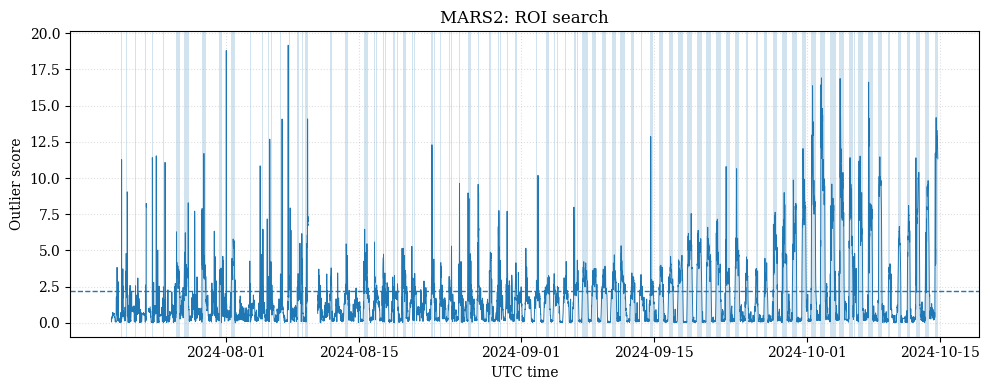

In [17]:
%matplotlib inline

fig, _ax = plot_scores_with_rois(
    df_scores,
    rois,
    threshold=threshold,
    title=("MARS2: ROI search"),
)
plt.tight_layout()
plt.show()

In [20]:
len(rois)

235

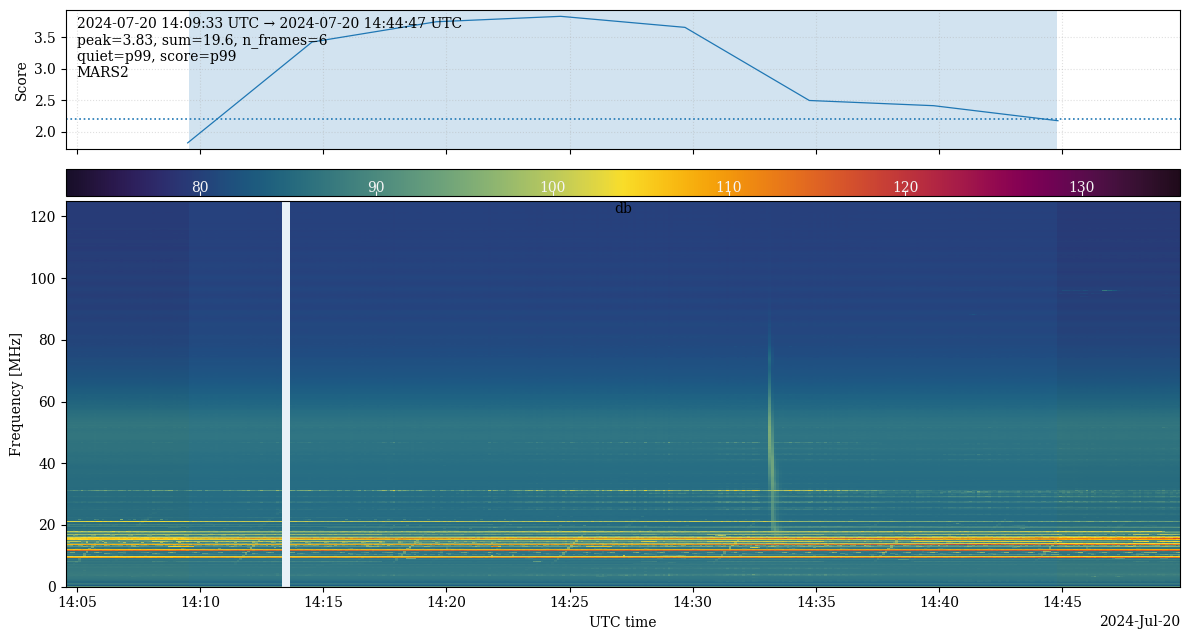

In [18]:
%matplotlib inline

fig, _axs = plot_roi_event(
    station="MARS2",
    roi=rois[0],
    df_scores=df_scores,
    zarr_path=zarr_path,
    chans=(0, 1),
    pipe=pipe_stokes_i_db,
    plot_pad_minutes=5,
    threshold=threshold,
    quiet_label="p99",
    score_label="p99",
)

In [26]:
for i, roi in enumerate(rois):
    fig, _axs = plot_roi_event(
        station="MARS3",
        roi=roi,
        df_scores=df_scores,
        zarr_path=zarr_path,
        chans=(0, 1),
        pipe=pipe_stokes_i_db,
        plot_pad_minutes=5,
        threshold=threshold,
        quiet_label="p99",
        score_label="p99",
        
    )

    roi_tag = pd.to_datetime(roi.start, utc=True).strftime("%Y%m%d_%H%M%S")
    fig.savefig(
        f"processing/MARS3/roi/roi_{i:04d}.png",
        dpi=144,
        bbox_inches="tight",
    )
    plt.close(fig)

## GOES X-Ray Flux

- [goes-r-extreme-ultraviolet-xray-irradiance](https://www.ncei.noaa.gov/products/goes-r-extreme-ultraviolet-xray-irradiance)
- [space-weather-portal](https://lasp.colorado.edu/space-weather-portal)
- [GOES_XRS_readme.pdf](https://www.ngdc.noaa.gov/stp/satellite/goes/doc/GOES_XRS_readme.pdf)
- [GOES-R_EXIS_XRS_L1b_Data_ReadMe.pdf](https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/goes16/l1b/docs/GOES-R_EXIS_XRS_L1b_Data_ReadMe.pdf)
- [latis-swp-notebook.ipynb](https://github.com/lasp/latis-notebooks/blob/main/latis-swp-notebook.ipynb)

In [96]:
def latis_query_url(dataset, suffix="csv", projections=[], min_time="", max_time="", operations=[]):
    """Generates a LaTiS Space Weather Data Portal query URL with the given components."""
    base = "https://lasp.colorado.edu/space-weather-portal/latis/dap/"
    query = base + dataset + "." + suffix + "?"
    if projections:
        query += ",".join(projections)
    if min_time:
        query += "&time>=" + min_time  # note: could use "time>"
    if max_time:
        query += "&time<" + max_time   # note: could use "time<="
    if operations:
        query += "&" + "&".join(operations)
    return query

def fetch_goes_xrs(start: str, stop: str, dataset="noaa_goes18_xrs_1m"):
    query = latis_query_url(
        dataset,
        suffix="csv",
        projections=["time", "shortwave", "longwave"],
        min_time=start,
        max_time=stop,
        operations=["formatTime(yyyy-MM-dd'T'HH:mm:ss)", "excludeMissing()"],
    )

    df = pd.read_csv(query, parse_dates=["time (yyyy-MM-dd'T'HH:mm:ss)"])
    df = df.rename(columns={
        "time (yyyy-MM-dd'T'HH:mm:ss)": "time",
        "shortwave (W/m^2)": "xrs_short",
        "longwave (W/m^2)": "xrs_long",
    })
    # df = df.set_index("time").sort_index()

    return df

In [97]:
df = fetch_goes_xrs(start="2024-07-01", stop="2024-07-03", dataset="noaa_goes18_xrs_1m")
df.head()

,time,xrs_short,xrs_long
0,2024-07-01 00:00:00,4.840852e-08,0.000002
1,2024-07-01 00:01:00,4.925153e-08,0.000002
2,2024-07-01 00:02:00,5.004213e-08,0.000002
3,2024-07-01 00:03:00,5.272209e-08,0.000002
4,2024-07-01 00:04:00,4.996779e-08,0.000002


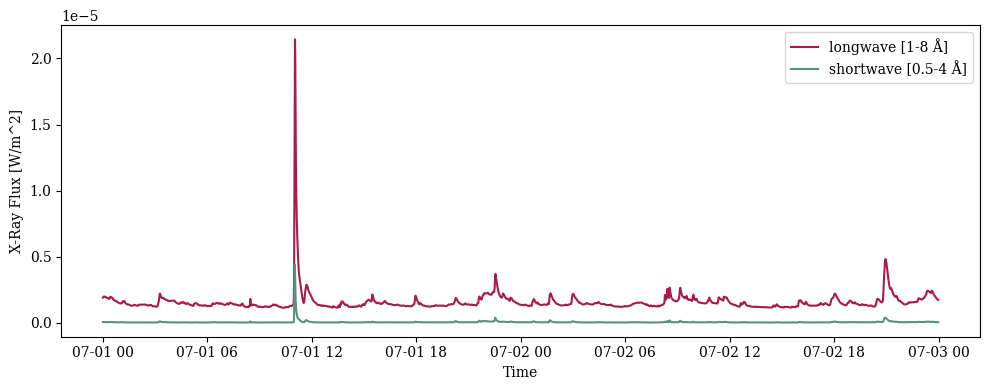

In [114]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["time"], df["xrs_long"], color=cmr.pride(0.8), label="longwave [1-8 Å]")
ax.plot(df["time"], df["xrs_short"], color=cmr.pride(0.3), label="shortwave [0.5-4 Å]")

ax.set_xlabel("Time")
ax.set_ylabel("X-Ray Flux [W/m^2]")

plt.legend()

plt.tight_layout()
plt.show()